In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

os.chdir(r'D:\pku\UES\GlobalForestVerticalStructure\China_plantation_natural_forest\revise_data_20251210\25km')

In [2]:
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
df_list = [pd.read_csv(f) for f in csv_files]
df_data = pd.concat(df_list, ignore_index=True)

In [9]:
df_data.columns.values

array(['system:index', 'batch', 'nat_b1', 'nat_b10', 'nat_b11', 'nat_b12',
       'nat_b13', 'nat_b14', 'nat_b15', 'nat_b16', 'nat_b17', 'nat_b18',
       'nat_b19', 'nat_b2', 'nat_b3', 'nat_b4', 'nat_b5', 'nat_b6',
       'nat_b7', 'nat_b8', 'nat_b9', 'nat_clay_0-5cm_mean',
       'nat_clay_100-200cm_mean', 'nat_clay_15-30cm_mean',
       'nat_clay_30-60cm_mean', 'nat_clay_5-15cm_mean',
       'nat_clay_60-100cm_mean', 'nat_cover', 'nat_delta_time',
       'nat_digital_elevation_model', 'nat_fhd_normal', 'nat_forest_age',
       'nat_nitrogen_0-5cm_mean', 'nat_nitrogen_100-200cm_mean',
       'nat_nitrogen_15-30cm_mean', 'nat_nitrogen_30-60cm_mean',
       'nat_nitrogen_5-15cm_mean', 'nat_nitrogen_60-100cm_mean',
       'nat_pai', 'nat_phh2o_0-5cm_mean', 'nat_phh2o_100-200cm_mean',
       'nat_phh2o_15-30cm_mean', 'nat_phh2o_30-60cm_mean',
       'nat_phh2o_5-15cm_mean', 'nat_phh2o_60-100cm_mean', 'nat_rh98',
       'nat_soc_0-5cm_mean', 'nat_soc_100-200cm_mean',
       'nat_soc_15-30

In [3]:
df_data_nonull = df_data[((df_data['nat_rh98']!='[]') & (df_data['plt_rh98']!='[]'))]

In [4]:
df_data.shape,df_data_nonull.shape

((25325, 104), (8758, 104))

In [5]:
# first footprints check
df_data_nonull_n = (eval(i) for i in df_data_nonull['nat_rh98'].values)
df_data_nonull_n = [item for sublist in df_data_nonull_n for item in sublist]
df_data_nonull_p = (eval(i) for i in df_data_nonull['plt_rh98'].values)
df_data_nonull_p = [item for sublist in df_data_nonull_p for item in sublist]
print('#L2A&L2B','natural forest footprints',len(df_data_nonull_n),'planted forest footprints',len(df_data_nonull_p))
print('number of grids', len(df_data_nonull))

#L2A&L2B natural forest footprints 27070139 planted forest footprints 7562531
number of grids 8758


In [31]:
# check forest age distribution
df_data_nonull_n_age = [eval(i) for i in df_data_nonull['nat_forest_age'].values]
df_data_nonull_p_age = [eval(i) for i in df_data_nonull['plt_forest_age'].values]
df_data_nonull_n_age_flatten = [item for sublist in df_data_nonull_n_age for item in sublist if item != -9999]
df_data_nonull_p_age_flatten = [item for sublist in df_data_nonull_p_age for item in sublist if item != -9999]

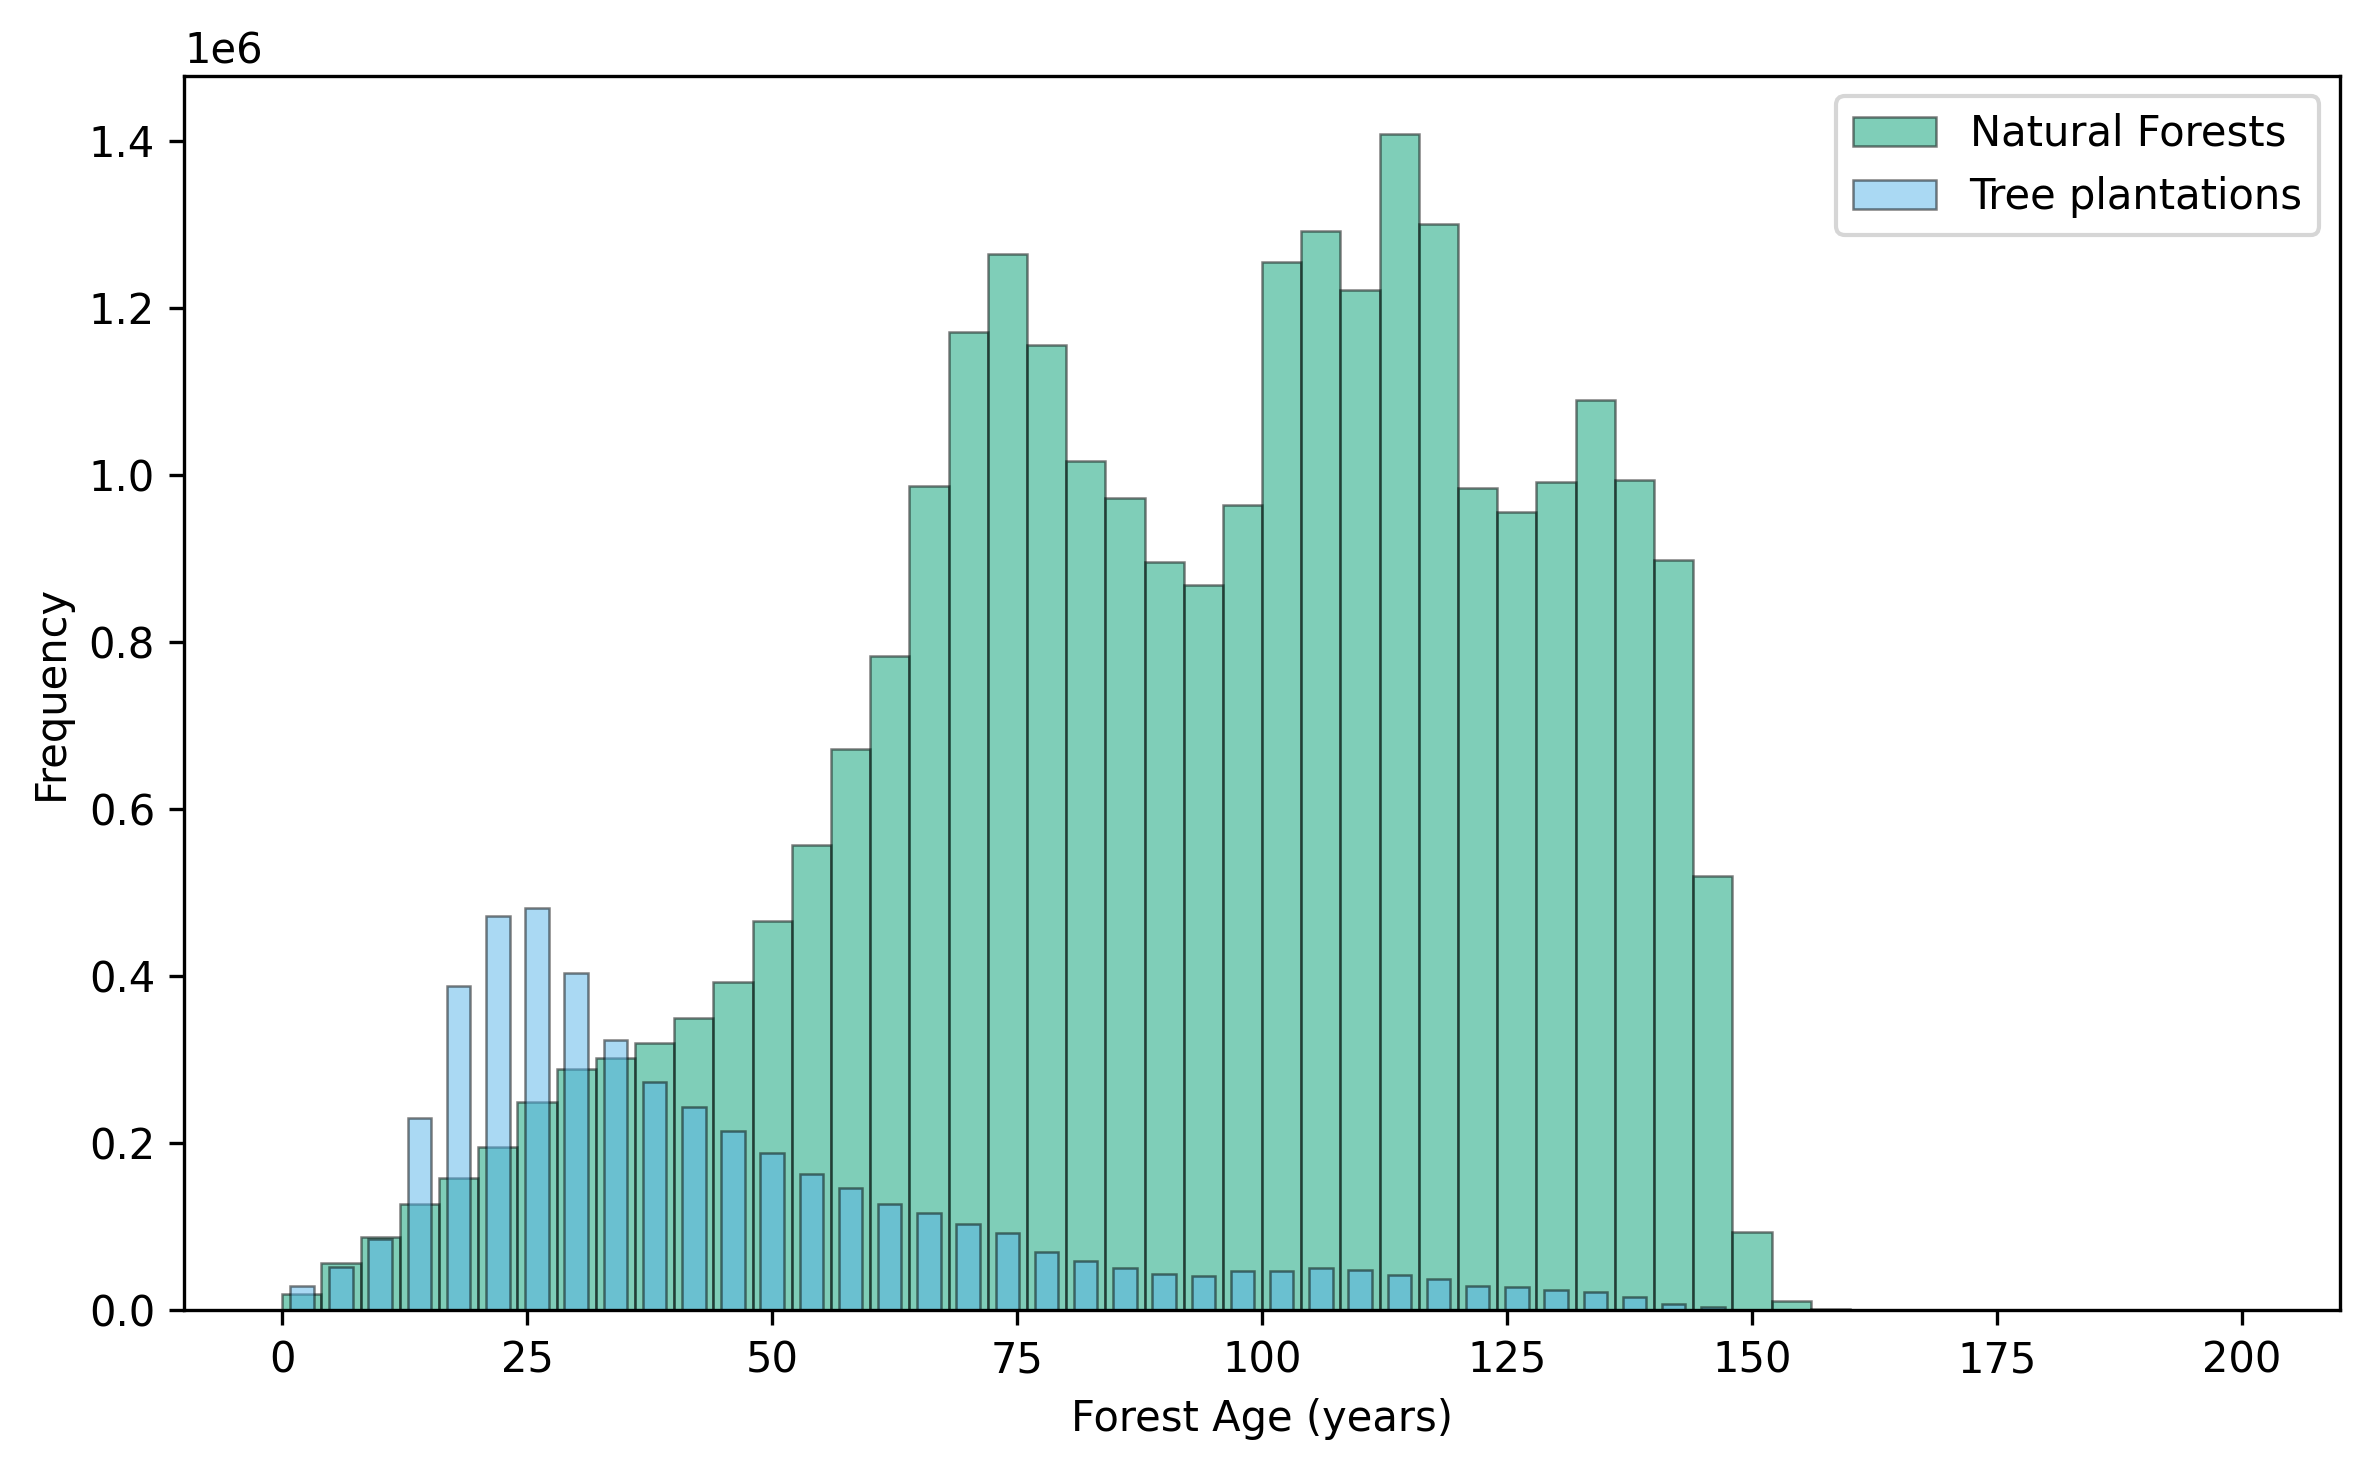

In [32]:
bin_start = 0
bin_end = 200
bin_num = 50
bins = np.linspace(bin_start, bin_end, bin_num+1)

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.hist(df_data_nonull_n_age_flatten, bins=bins, alpha=0.5,linewidth=0.6,
        label='Natural Forests', facecolor='#009E73', edgecolor='black')
ax.hist(df_data_nonull_p_age_flatten, bins=bins, alpha=0.5,linewidth=0.6, rwidth = 0.6,
        label='Tree plantations', facecolor='#56B4E9', edgecolor='black')

ax.set_xlabel('Forest Age (years)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig('./figs/forest_age_distribution_overlay.png', dpi=300)

In [14]:
# check forest age distribution
df_data_nonull_n_time = [eval(i) for i in df_data_nonull['nat_delta_time'].values]
df_data_nonull_p_time = [eval(i) for i in df_data_nonull['plt_delta_time'].values]
df_data_nonull_n_time_flatten = [item for sublist in df_data_nonull_n_time for item in sublist if item != -9999]
df_data_nonull_p_time_flatten = [item for sublist in df_data_nonull_p_time for item in sublist if item != -9999]

In [16]:
df_data_nonull_n_time_flatten_day = [i/60/60/24 for i in df_data_nonull_n_time_flatten]
df_data_nonull_p_time_flatten_day = [i/60/60/24 for i in df_data_nonull_p_time_flatten]

In [22]:
np.max(df_data_nonull_p_time_flatten_day)

np.float64(2462.531628220197)

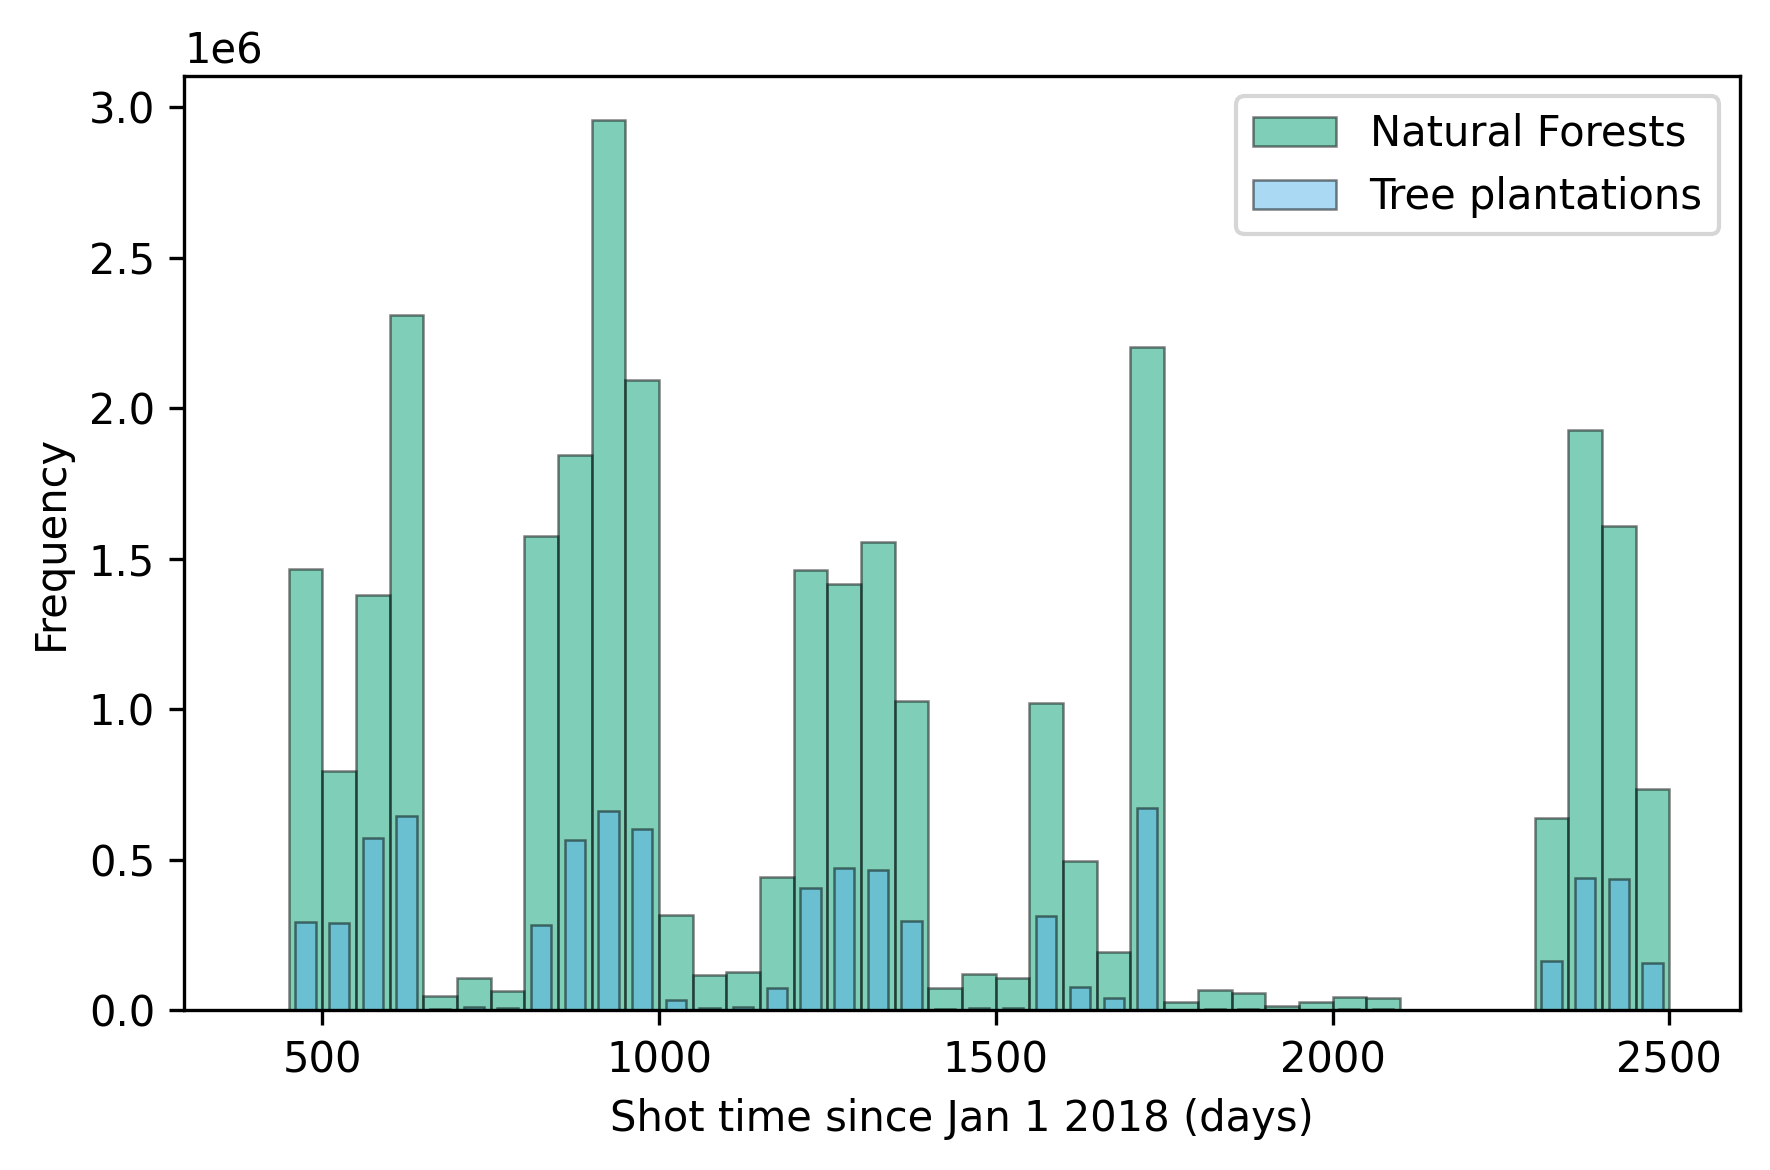

In [30]:
bin_start = 400
bin_end = 2500
bin_num = 42
bins = np.linspace(bin_start, bin_end, bin_num+1)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.hist(df_data_nonull_n_time_flatten_day, bins=bins, alpha=0.5, linewidth=0.6,
        label='Natural Forests', facecolor='#009E73', edgecolor='black')
ax.hist(df_data_nonull_p_time_flatten_day, bins=bins, alpha=0.5, linewidth=0.6, rwidth = 0.6,
        label='Tree plantations', facecolor='#56B4E9', edgecolor='black')

ax.set_xlabel('Shot time since Jan 1 2018 (days)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig('./figs/forest_shottime_distribution_overlay.png', dpi=300)

In [10]:
df_data_nonull_n_age_gridmean = [np.mean([item for item in sublist if item != -9999]) for sublist in df_data_nonull_n_age]
df_data_nonull_p_age_gridmean = [np.mean([item for item in sublist if item != -9999]) for sublist in df_data_nonull_p_age]

c:\Users\admin\.conda\envs\nicenv\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\admin\.conda\envs\nicenv\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Distribution of Forest Ages')

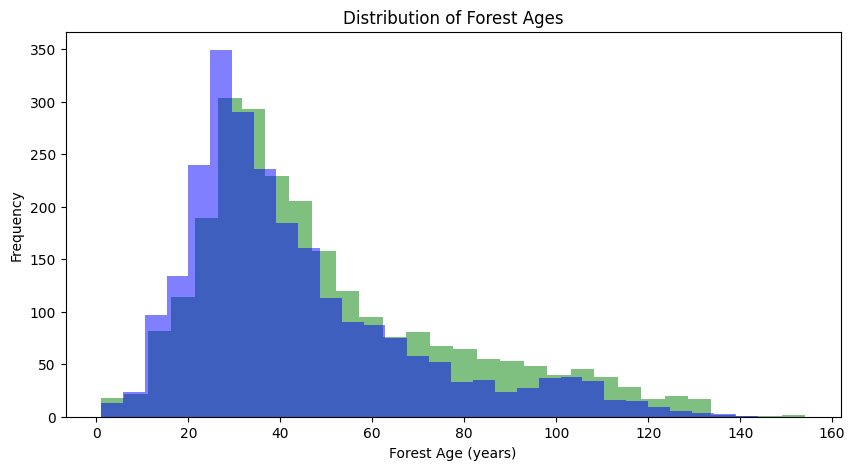

In [11]:
# plot distribution
plt.figure(figsize=(10, 5))
plt.hist(df_data_nonull_n_age_gridmean, bins=30, alpha=0.5, label='Natural Forest Age', color='green')
plt.hist(df_data_nonull_p_age_gridmean, bins=30, alpha=0.5, label='Planted Forest Age', color='blue')
plt.xlabel('Forest Age (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Forest Ages')

In [6]:
def random_mean(array):
    length = len(array)
    sample_index = np.random.choice(length, size=length, replace=True, p=None)
    # print(sample_index)
    sample_data = array[sample_index]
    sample_data = sample_data[sample_data != -9999].mean()
    return sample_data

def all_mean(array):
    array = array[array != -9999]
    if len(array) == 0:
        return np.nan
    else:
        return array.mean()

def bootstrap_mean_for_bins(data_group: pd.DataFrame, n_bootstrap: int, N_sample: int) -> pd.Series:
    means_list = []
    # print(f"Bootstrapping for group with {N} samples.")
    for _ in range(n_bootstrap):
        sample = data_group.sample(n=N_sample, replace=True)
        means = sample.mean()
        means_list.append(means)
        
    bootstrap_results = pd.DataFrame(means_list)

    final_mean = bootstrap_results.mean()
    
    return final_mean

In [7]:
from scipy import stats
NAT_TIME_COL = 'nat_delta_time' 
PLT_TIME_COL = 'plt_delta_time' 
MIN_SAMPLE_SIZE = 50
SIGNIFICANCE_LEVEL = 0.05
nat_columns = [col for col in df_data_nonull.columns if col.startswith('nat')]
plt_columns = [col for col in df_data_nonull.columns if col.startswith('plt')]

def process_row_temp(row, nat_columns, plt_columns) -> dict | None:

    nat_rh_all_i = pd.DataFrame({col: eval(row[col]) for col in nat_columns})
    plt_rh_all_i = pd.DataFrame({col: eval(row[col]) for col in plt_columns})

    nat_mask = (nat_rh_all_i > -9999).all(axis=1)
    plt_mask = (plt_rh_all_i > -9999).all(axis=1)
    
    nat_df = nat_rh_all_i[nat_mask].copy()
    plt_df = plt_rh_all_i[plt_mask].copy()

    if len(nat_df.get('nat_rh98', [])) < MIN_SAMPLE_SIZE or \
       len(plt_df.get('plt_rh98', [])) < MIN_SAMPLE_SIZE:
        return None
    

    if NAT_TIME_COL not in nat_df.columns or PLT_TIME_COL not in plt_df.columns:
        return None

    nat_time = nat_df[NAT_TIME_COL].values
    plt_time = plt_df[PLT_TIME_COL].values

    difference = nat_time.mean() - plt_time.mean()

    return {
        'Day_diff': difference/60/60/24,
    }

In [ ]:
time_difference = Parallel(n_jobs=6)(delayed(process_row_temp)(df_data_nonull.iloc[i], nat_columns, plt_columns) for i in range(df_data_nonull.shape[0]))
time_difference = [res for res in time_difference if res is not None]

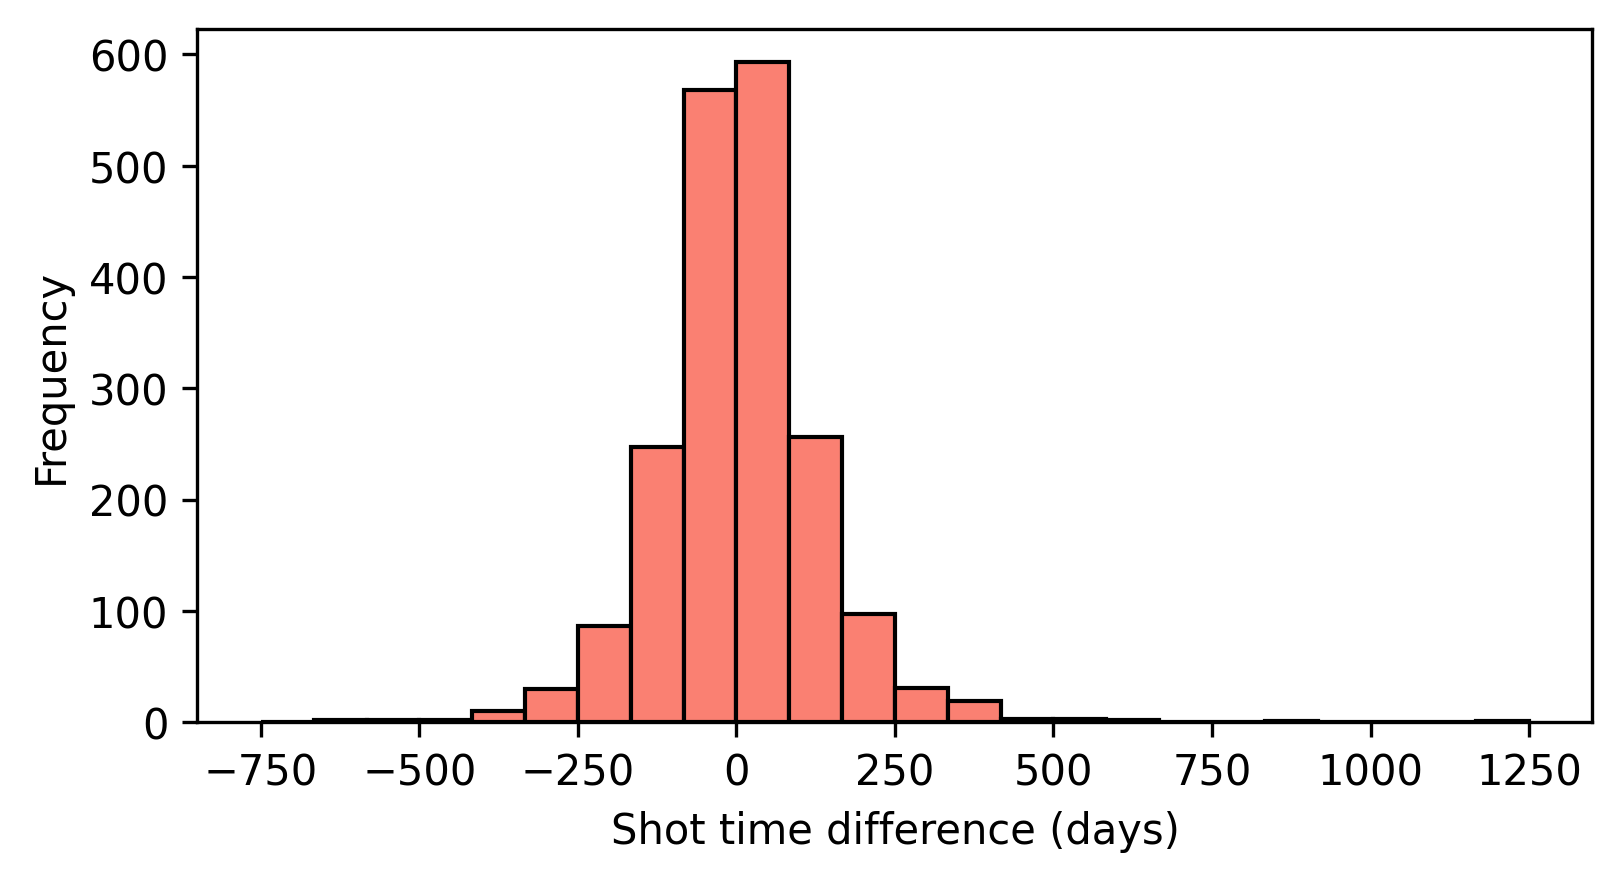

In [ ]:
#plot time difference distribution
bins = np.linspace(-750, 1250, 25)

plt.figure(figsize=(6, 3),dpi=300)
plt.hist([res['Day_diff'] for res in time_difference], bins=bins, alpha=1,
            label='Time Difference', color='salmon',edgecolor='black')
plt.xlabel('Shot time difference (days)')
plt.ylabel('Frequency')

plt.savefig('./figs/forest_shottime_difference_distribution.png', dpi=300)
plt.show()

In [11]:
# parallel version ~1h
def process_row(row):
    nat_rh_all_i = pd.DataFrame({col: eval(row[col]) for col in nat_columns})
    plt_rh_all_i = pd.DataFrame({col: eval(row[col]) for col in plt_columns})

    # mask
    nat_mask = (nat_rh_all_i > -9999).all(axis=1)
    plt_mask = (plt_rh_all_i > -9999).all(axis=1)
    nat_rh_all_i = nat_rh_all_i[nat_mask]
    plt_rh_all_i = plt_rh_all_i[plt_mask]

    # Control sample
    if len(nat_rh_all_i['nat_rh98']) < 50 or len(plt_rh_all_i['plt_rh98']) < 50:
        return None

    # DEM filter
    ele_all = pd.concat([nat_rh_all_i['nat_digital_elevation_model'], plt_rh_all_i['plt_digital_elevation_model']])
    ele_p10, ele_p90 = np.percentile(ele_all, [10, 90])
    ele_min = max(ele_all.min(), ele_p10)
    ele_max = min(ele_all.max(), ele_p90)
    nat_rh_all_i = nat_rh_all_i[(nat_rh_all_i['nat_digital_elevation_model'] > ele_min) & (nat_rh_all_i['nat_digital_elevation_model'] < ele_max)]
    plt_rh_all_i = plt_rh_all_i[(plt_rh_all_i['plt_digital_elevation_model'] > ele_min) & (plt_rh_all_i['plt_digital_elevation_model'] < ele_max)]

    min_sample_num = min(len(nat_rh_all_i), len(plt_rh_all_i))
    if min_sample_num < 50:
        return None

    # AGE stratified
    age_min = max(nat_rh_all_i['nat_forest_age'].min(), plt_rh_all_i['plt_forest_age'].min())
    age_max = min(nat_rh_all_i['nat_forest_age'].max(), plt_rh_all_i['plt_forest_age'].max())
    
    if age_max <= age_min:
        return None
    
    bins = np.arange(age_min, age_max + 10, 10)
    nat_rh_all_i['age_bin'] = pd.cut(nat_rh_all_i['nat_forest_age'], bins=bins)
    plt_rh_all_i['age_bin'] = pd.cut(plt_rh_all_i['plt_forest_age'], bins=bins)
    
    nat_valid_bins = nat_rh_all_i['age_bin'].value_counts()[nat_rh_all_i['age_bin'].value_counts() >= 1].index
    plt_valid_bins = plt_rh_all_i['age_bin'].value_counts()[plt_rh_all_i['age_bin'].value_counts() >= 1].index
    
    common_bins = nat_valid_bins.intersection(plt_valid_bins)
    if common_bins.empty:
        return None

    if 1: #weighted mean by age bins
        nat_in_bins = nat_rh_all_i[nat_rh_all_i['age_bin'].isin(common_bins)]
        plt_in_bins = plt_rh_all_i[plt_rh_all_i['age_bin'].isin(common_bins)]

        nat_bin_counts = nat_in_bins['age_bin'].value_counts().sort_index()
        plt_bin_counts = plt_in_bins['age_bin'].value_counts().sort_index()
        print(nat_bin_counts,plt_bin_counts)
        N_bin_counts = nat_bin_counts.combine(plt_bin_counts, lambda x, y: np.nanmin([x, y]))
        print(N_bin_counts)
        nat_bin_means = nat_in_bins.groupby('age_bin').apply(lambda group: bootstrap_mean_for_bins(group, n_bootstrap=100, N_sample=N_bin_counts.loc[group.name]))
        plt_bin_means = plt_in_bins.groupby('age_bin').apply(lambda group: bootstrap_mean_for_bins(group, n_bootstrap=100, N_sample=N_bin_counts.loc[group.name]))

        nat_rh_all_i_mean_list = nat_bin_means.mean(numeric_only=True).values
        plt_rh_all_i_mean_list = plt_bin_means.mean(numeric_only=True).values

        # #sample size
        # nat_sample_size = nat_bin_counts.isin(common_bins).sum()
        # plt_sample_size = plt_bin_counts.isin(common_bins).sum()

    if 0: #mean of means
        nat_means = nat_rh_all_i[nat_rh_all_i['age_bin'].isin(common_bins)].groupby('age_bin').mean(numeric_only=True)
        plt_means = plt_rh_all_i[plt_rh_all_i['age_bin'].isin(common_bins)].groupby('age_bin').mean(numeric_only=True)
        print(nat_means['nat_rh98'],plt_means['plt_rh98'])
        nat_rh_all_i_mean_list = nat_means.mean(numeric_only=True).values
        plt_rh_all_i_mean_list = plt_means.mean(numeric_only=True).values

    return {
        'grid_id': row['system:index'],
        'min_sample_num': min_sample_num,
        'nat_sample_size': len(nat_rh_all_i),
        'plt_sample_size': len(plt_rh_all_i),
        **dict(zip(nat_columns, nat_rh_all_i_mean_list)),
        **dict(zip(plt_columns, plt_rh_all_i_mean_list))
    }

In [9]:
result_test = process_row(df_data_nonull.iloc[730])
result_test

age_bin
(15, 25]      0
(25, 35]    114
(35, 45]    188
(45, 55]    252
(55, 65]      0
Name: count, dtype: int64 age_bin
(15, 25]      0
(25, 35]     78
(35, 45]    104
(45, 55]     22
(55, 65]      0
Name: count, dtype: int64
age_bin
(15, 25]      0
(25, 35]     78
(35, 45]    104
(45, 55]     22
(55, 65]      0
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_82688\4162920922.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nat_bin_means = nat_in_bins.groupby('age_bin').apply(lambda group: bootstrap_mean_for_bins(group, n_bootstrap=100, N_sample=N_bin_counts.loc[group.name]))
C:\Users\admin\AppData\Local\Temp\ipykernel_82688\4162920922.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt_bin_means = plt_in_bins.groupby('age_bin').apply(lambda group: bootstrap_mean_for_bins(group, n_bootstrap=100, N_sample=N_bin_counts.loc[group.name]))


{'grid_id': '566,229',
 'min_sample_num': 213,
 'nat_sample_size': 794,
 'plt_sample_size': 213,
 'nat_b1': np.float64(3.587316307292152),
 'nat_b10': np.float64(20.75257499386558),
 'nat_b11': np.float64(-15.833109170050506),
 'nat_b12': np.float64(552.3779011266511),
 'nat_b13': np.float64(157.54563714063715),
 'nat_b14': np.float64(3.0),
 'nat_b15': np.float64(109.48590116354701),
 'nat_b16': np.float64(366.1475514763015),
 'nat_b17': np.float64(12.350087412587413),
 'nat_b18': np.float64(366.1475514763015),
 'nat_b19': np.float64(12.350087412587413),
 'nat_b2': np.float64(11.754828363222614),
 'nat_b3': np.float64(22.78519119032343),
 'nat_b4': np.float64(1479.8237817569927),
 'nat_b5': np.float64(26.861312024087027),
 'nat_b6': np.float64(-24.728395194250194),
 'nat_b7': np.float64(51.58970764375874),
 'nat_b8': np.float64(20.75257499386558),
 'nat_b9': np.float64(-15.833109170050506),
 'nat_clay_0-5cm_mean': np.float64(285.84056721056726),
 'nat_clay_100-200cm_mean': np.float64(3

In [12]:
# 11 min
results = Parallel(n_jobs=6)(delayed(process_row)(df_data_nonull.iloc[i]) for i in range(df_data_nonull.shape[0])) #df_data_nonull.shape[0]
df_bootstrap = pd.DataFrame([res for res in results if res is not None])

In [65]:
df_bootstrap.describe()

,min_sample_num,nat_sample_size,plt_sample_size,nat_b1,nat_b10,nat_b11,nat_b12,nat_b13,nat_b14,nat_b15,...,plt_phh2o_30-60cm_mean,plt_phh2o_5-15cm_mean,plt_phh2o_60-100cm_mean,plt_rh98,plt_soc_0-5cm_mean,plt_soc_100-200cm_mean,plt_soc_15-30cm_mean,plt_soc_30-60cm_mean,plt_soc_5-15cm_mean,plt_soc_60-100cm_mean
count,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,...,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000
mean,1112.056150,10941.033155,1839.604278,10.318013,21.622937,-2.277642,999.195364,197.084016,16.407359,83.030051,...,61.234192,60.758346,61.637539,15.001814,557.095011,102.729068,198.315950,139.636425,318.486177,104.384536
std,1734.729185,28006.640112,2614.257761,7.491608,3.970034,12.126181,445.222384,61.040257,14.903055,22.004851,...,5.662173,5.754358,5.691448,2.412661,241.952870,81.289836,79.692448,66.617847,143.910810,63.234119
min,50.000000,50.000000,50.000000,-5.551808,9.023877,-26.359926,254.406904,46.308948,0.821930,39.121680,...,49.634883,49.484142,50.236068,7.729908,130.350574,28.725737,75.288482,49.924075,94.991057,35.814686
25%,198.000000,386.500000,341.750000,3.127947,18.665986,-14.680140,578.767554,146.222748,3.987226,62.692004,...,57.564613,56.864555,57.919509,13.463537,380.485561,48.729404,136.337840,86.947873,204.663241,57.478934
50%,512.000000,1101.000000,980.500000,12.643983,21.411551,3.113935,919.438000,186.032514,9.869791,82.751010,...,60.153173,59.679391,60.426714,15.068683,468.057407,72.156497,173.342179,120.062307,267.504029,80.183625
75%,1336.750000,3804.250000,2370.250000,16.469920,25.385792,7.026696,1411.430402,242.449389,28.927378,102.283020,...,63.403719,62.978029,63.928589,16.637389,706.565634,136.401153,258.609221,181.570080,438.515144,138.036367
max,29120.000000,258196.000000,32374.000000,25.028463,28.822264,20.986024,2188.655128,417.150805,51.468170,132.141669,...,81.022838,80.930163,81.402583,27.637615,1340.299331,680.804820,598.878804,616.267774,775.535719,580.198527


In [13]:
df_bootstrap.to_csv('china_grids_result_masknan4_bootstrap_agematch_unweighted_samplenum_v2_25km.csv', index=False)

In [36]:
df_bootstrap.columns

Index(['grid_id', 'min_sample_num', 'nat_b1', 'nat_b10', 'nat_b11', 'nat_b12',
       'nat_b13', 'nat_b14', 'nat_b15', 'nat_b16', 'nat_b17', 'nat_b18',
       'nat_b19', 'nat_b2', 'nat_b3', 'nat_b4', 'nat_b5', 'nat_b6', 'nat_b7',
       'nat_b8', 'nat_b9', 'nat_clay_0-5cm_mean', 'nat_clay_100-200cm_mean',
       'nat_clay_15-30cm_mean', 'nat_clay_30-60cm_mean',
       'nat_clay_5-15cm_mean', 'nat_clay_60-100cm_mean', 'nat_cover',
       'nat_digital_elevation_model', 'nat_fhd_normal', 'nat_forest_age',
       'nat_nitrogen_0-5cm_mean', 'nat_nitrogen_100-200cm_mean',
       'nat_nitrogen_15-30cm_mean', 'nat_nitrogen_30-60cm_mean',
       'nat_nitrogen_5-15cm_mean', 'nat_nitrogen_60-100cm_mean', 'nat_pai',
       'nat_phh2o_0-5cm_mean', 'nat_phh2o_100-200cm_mean',
       'nat_phh2o_15-30cm_mean', 'nat_phh2o_30-60cm_mean',
       'nat_phh2o_5-15cm_mean', 'nat_phh2o_60-100cm_mean', 'nat_rh98',
       'nat_soc_0-5cm_mean', 'nat_soc_100-200cm_mean', 'nat_soc_15-30cm_mean',
       'nat_soc_30

In [112]:
from scipy import stats

df_test_result = pd.DataFrame(dtype = float)
range_i = range(50,500,1)

def ttest_rel_mean_dif(a, b):
    mask = (~pd.isna(a)) & (~pd.isna(b))
    a_clean = a[mask]
    b_clean = b[mask]
    test_p = stats.ttest_rel(a_clean, b_clean).pvalue
    mean_diff = a_clean.mean() - b_clean.mean()
    return test_p, mean_diff

for i in range_i:
    df_test = df_bootstrap[df_bootstrap['min_sample_num'] >= i]

    ttest_rh98, rh98_mean_diff = ttest_rel_mean_dif(df_test['nat_rh98'],df_test['plt_rh98'])
    ttest_fhd, fhd_mean_diff = ttest_rel_mean_dif(df_test['nat_fhd_normal'],df_test['plt_fhd_normal'])
    ttest_pai, pai_mean_diff = ttest_rel_mean_dif(df_test['nat_pai'],df_test['plt_pai'])
    ttest_cov, cov_mean_diff = ttest_rel_mean_dif(df_test['nat_cover'],df_test['plt_cover'])
    
    df_test_result.loc[i-20,'rh98_ttest_p'] = ttest_rh98
    df_test_result.loc[i-20,'rh98_mean_diff'] = rh98_mean_diff

    df_test_result.loc[i-20,'fhd_ttest_p'] = ttest_fhd
    df_test_result.loc[i-20,'fhd_mean_diff'] = fhd_mean_diff

    df_test_result.loc[i-20,'pai_ttest_p'] = ttest_pai
    df_test_result.loc[i-20,'pai_mean_diff'] = pai_mean_diff

    df_test_result.loc[i-20,'cov_ttest_p'] = ttest_cov
    df_test_result.loc[i-20,'cov_mean_diff'] = cov_mean_diff

C:\Users\admin\AppData\Local\Temp\ipykernel_62768\2762763759.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


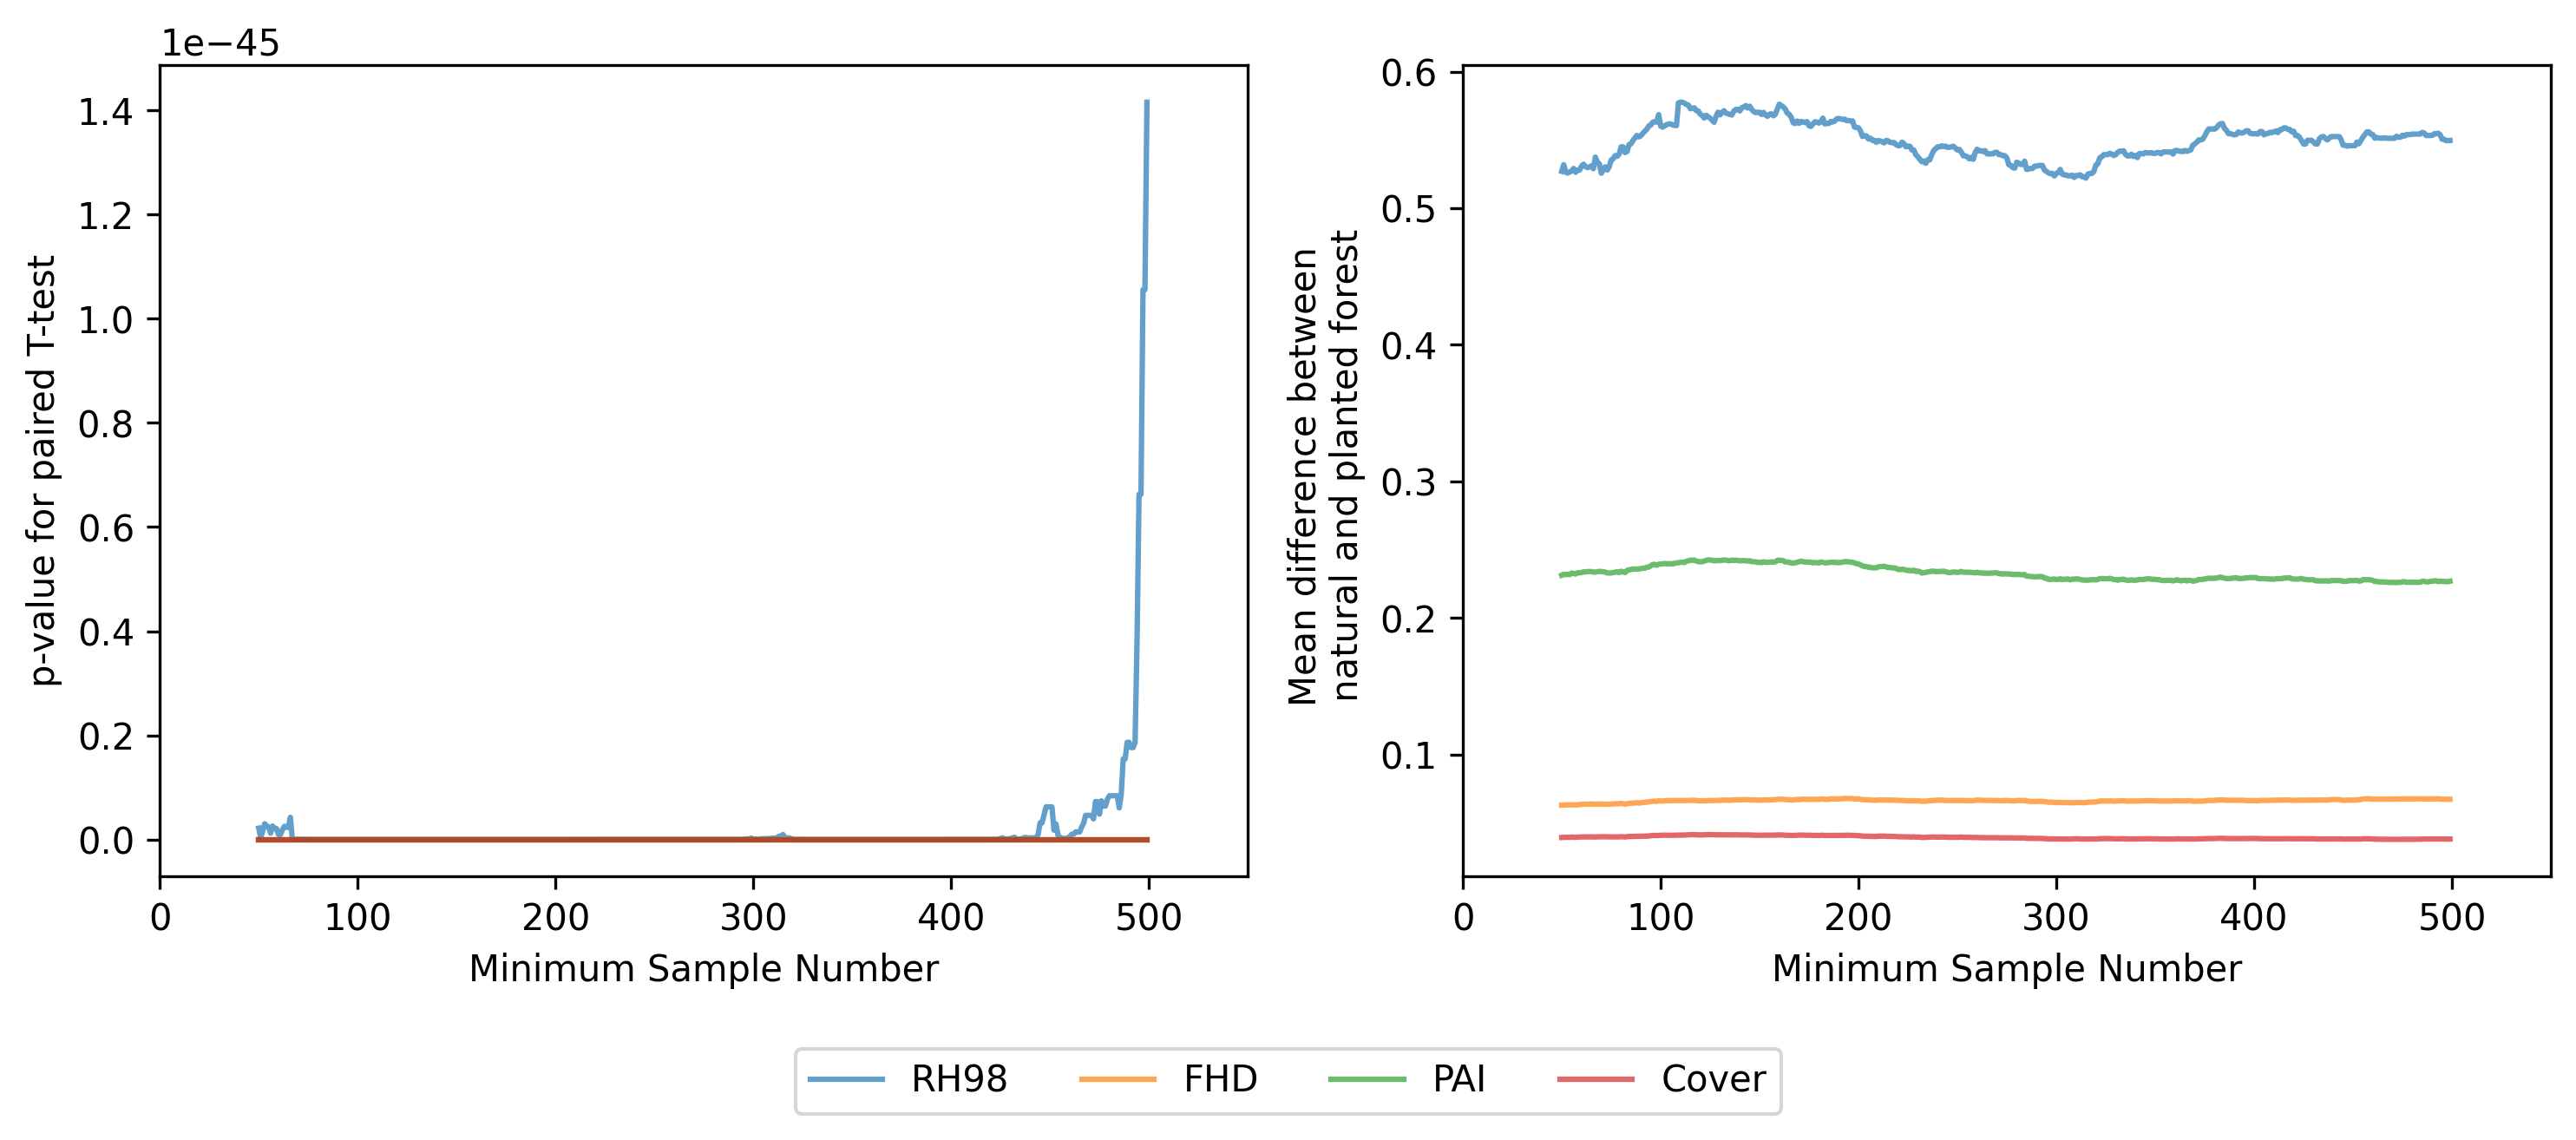

In [113]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# First subplot
axs[0].plot(np.array(range_i), df_test_result['rh98_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['fhd_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['pai_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['cov_ttest_p'], alpha=0.7)
axs[0].set_xlim(0,550)
axs[0].set_xlabel('Minimum Sample Number')
axs[0].set_ylabel('p-value for paired T-test')

# Second subplot
axs[1].plot(np.array(range_i), df_test_result['rh98_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['fhd_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['pai_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['cov_mean_diff'], alpha=0.7)
axs[1].set_xlim(0,550)
axs[1].set_xlabel('Minimum Sample Number')
axs[1].set_ylabel('Mean difference between \n natural and planted forest')

# Hide the legends in the individual subplots
for ax in axs.flat:
    ax.legend().set_visible(False)

# Create a single legend for the entire figure
fig.legend(['RH98', 'FHD', 'PAI', 'Cover'], loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.show()

In [69]:
#wilcoxon
df_test_result = pd.DataFrame(dtype = float)
range_i = range(50,500,1)

def wilcoxon_rel_mean_dif(a, b):
    mask = (~pd.isna(a)) & (~pd.isna(b))
    a_clean = a[mask]
    b_clean = b[mask]
    test_p = stats.wilcoxon(a_clean, b_clean).pvalue
    mean_diff = a_clean.mean() - b_clean.mean()
    return test_p, mean_diff


for i in range_i:
    df_test = df_bootstrap[df_bootstrap['min_sample_num'] >= i]

    test_rh98, rh98_mean_diff = wilcoxon_rel_mean_dif(df_test['nat_rh98'],df_test['plt_rh98'])
    test_fhd, fhd_mean_diff = wilcoxon_rel_mean_dif(df_test['nat_fhd_normal'],df_test['plt_fhd_normal'])
    test_pai, pai_mean_diff = wilcoxon_rel_mean_dif(df_test['nat_pai'],df_test['plt_pai'])
    test_cov, cov_mean_diff = wilcoxon_rel_mean_dif(df_test['nat_cover'],df_test['plt_cover'])
    
    df_test_result.loc[i-20,'rh98_ttest_p'] = test_rh98
    df_test_result.loc[i-20,'rh98_mean_diff'] = rh98_mean_diff

    df_test_result.loc[i-20,'fhd_ttest_p'] = test_fhd
    df_test_result.loc[i-20,'fhd_mean_diff'] = fhd_mean_diff

    df_test_result.loc[i-20,'pai_ttest_p'] = test_pai
    df_test_result.loc[i-20,'pai_mean_diff'] = pai_mean_diff

    df_test_result.loc[i-20,'cov_ttest_p'] = test_cov
    df_test_result.loc[i-20,'cov_mean_diff'] = cov_mean_diff

C:\Users\admin\AppData\Local\Temp\ipykernel_62768\2739289498.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


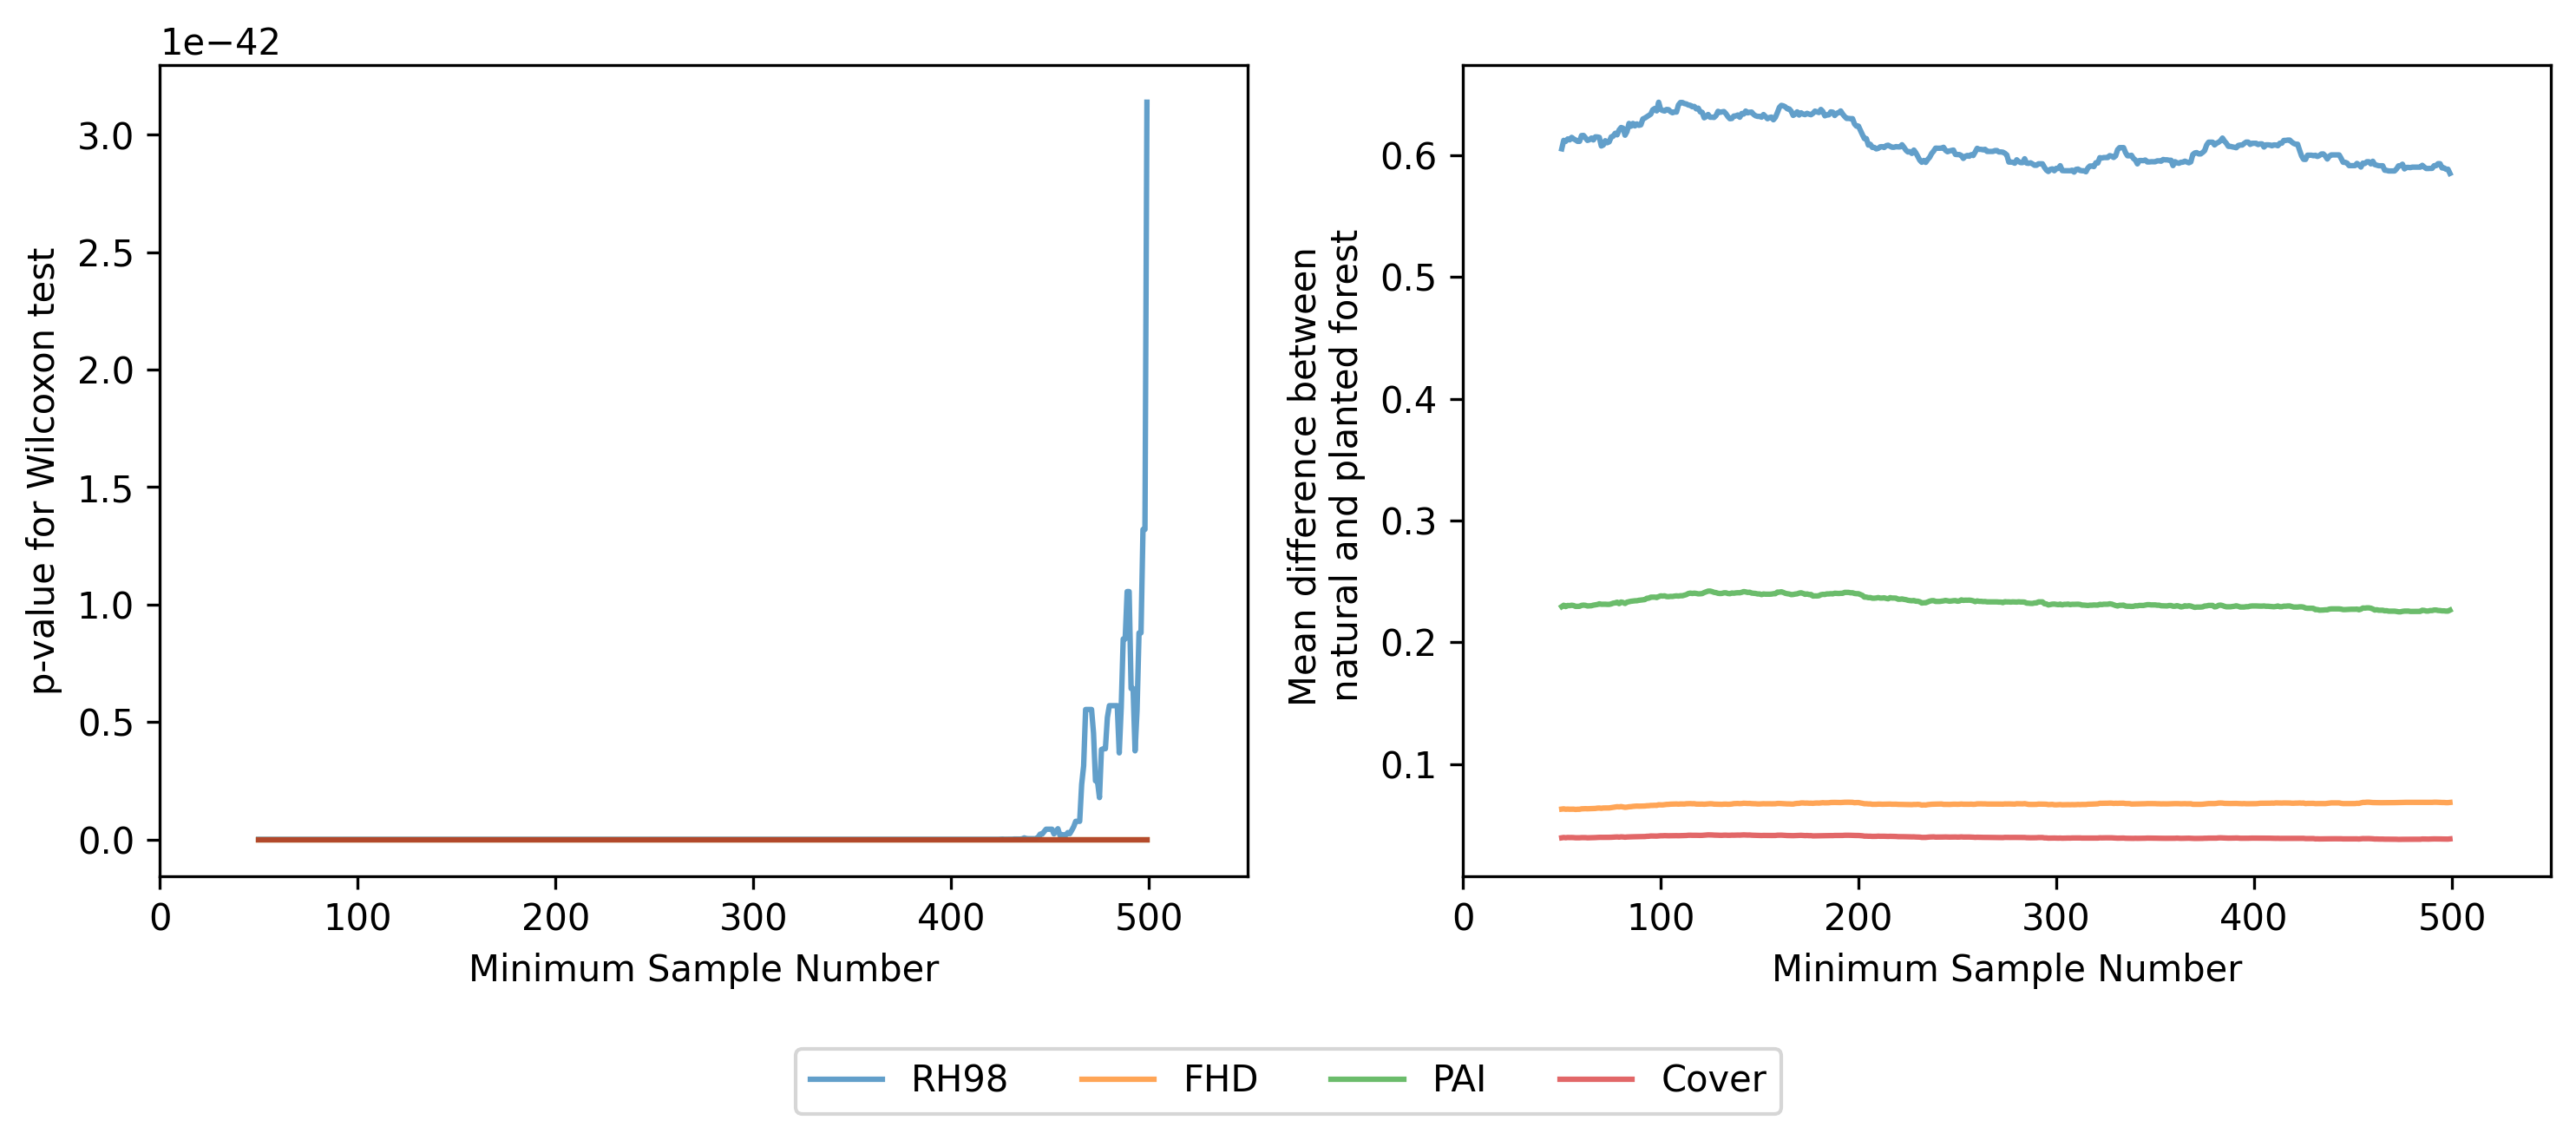

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# First subplot
axs[0].plot(np.array(range_i), df_test_result['rh98_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['fhd_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['pai_ttest_p'], alpha=0.7)
axs[0].plot(np.array(range_i), df_test_result['cov_ttest_p'], alpha=0.7)
axs[0].set_xlim(0,550)
axs[0].set_xlabel('Minimum Sample Number')
axs[0].set_ylabel('p-value for Wilcoxon test')

# Second subplot
axs[1].plot(np.array(range_i), df_test_result['rh98_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['fhd_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['pai_mean_diff'], alpha=0.7)
axs[1].plot(np.array(range_i), df_test_result['cov_mean_diff'], alpha=0.7)
axs[1].set_xlim(0,550)
axs[1].set_xlabel('Minimum Sample Number')
axs[1].set_ylabel('Mean difference between \n natural and planted forest')

# Hide the legends in the individual subplots
for ax in axs.flat:
    ax.legend().set_visible(False)

# Create a single legend for the entire figure
fig.legend(['RH98', 'FHD', 'PAI', 'Cover'], loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.show()

In [14]:
#second footprints check
df_new = df_bootstrap[(df_bootstrap['min_sample_num'] >= 50)]

nat_sample_size_all = df_new['nat_sample_size'].values.sum()
plt_sample_size_all = df_new['plt_sample_size'].values.sum()
print('#L2A&L2B','natural forest footprints',nat_sample_size_all,'planted forest footprints',plt_sample_size_all)
print(len(df_new))

#L2A&L2B natural forest footprints 15264163 planted forest footprints 2969851
4845


In [15]:
# make geopandas dataframe
df_new_geo = df_new.merge(df_data_nonull.rename(columns={'system:index':'grid_id'})[['grid_id','.geo']],how='left',on='grid_id')
print(len(df_new),len(df_new_geo))
geom = [shape(eval(i.replace('"geodesic":false,',''))) for i in df_new_geo['.geo']] #remove geodesic
df_new_geo.drop(['.geo'],axis=1,inplace=True)
df_new_geo = gpd.GeoDataFrame(df_new_geo,geometry=geom,crs='EPSG:3857')

4845 4845


In [16]:
veg_file = r'..\veg_class\china_veg_region_WGS84.shp'
veg_class = gpd.read_file(veg_file)
veg_class = veg_class.to_crs({'init': 'epsg:3857'})
df_new_geo_vclass = df_new_geo.sjoin(veg_class,lsuffix='')
#remove buffer on the edge of veg region
rep_count = df_new_geo_vclass['grid_id'].value_counts()
inside_index = rep_count.index[rep_count == 1]
df_new_geo_vclass_norep = df_new_geo_vclass[df_new_geo_vclass['grid_id'].isin(inside_index)]
print(len(df_new_geo_vclass_norep))

4618


c:\Users\admin\.conda\envs\nicenv\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [17]:
df_new_geo_vclass_norep['x'] = df_new_geo_vclass_norep.centroid.x
df_new_geo_vclass_norep['y'] = df_new_geo_vclass_norep.centroid.y

c:\Users\admin\.conda\envs\nicenv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\admin\.conda\envs\nicenv\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [18]:
df_new_geo_vclass_norep.to_file('gdf_new_factors_norep3_agematch_unweighted_samplenum_v2_25km.geojson', driver="GeoJSON")
df_new_geo_vclass_norep.to_csv('gdf_new_factors_norep_xy3_agematch_unweighted_samplenum_v2_25km.csv')